In [1]:
import math
import os
import time
from pathlib import Path
import numpy as np
from operator import itemgetter

import datasets
import torch
from transformers import AutoTokenizer
from torch.optim import AdamW
import torch.nn.functional as F
from gram_newton_schulz import Muon, POLAR_EXPRESS_COEFFICIENTS
from tqdm import tqdm

from nanomoe.data.packed_dataset import PackedPretrainStreamGroup, cu_seqlens_to_packing_metadata
from nanomoe.model import MoEConfig, create_model
from nanomoe.train import unified_loss
from nanomoe.optimizer import build_optimizer_muon, build_optimizer_adamw
from nanomoe.monitors import register_router_io_hooks


from nanomoe.monitors import (
    HiddenStateMonitorResult,
    NeighbourLayerHiddenStateStats,
    TokenHiddenStateLayerStats,
    hidden_state_cosine_similarities
)

%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt

def sample_random_P(P: np.ndarray, n_samples: int = 1000) -> np.ndarray:
    """
    Sample random matrices R with the same shape and Frobenius norm as P.
    
    P: (D, K)
    returns: (n_samples, D, K)
    """
    D, K = P.shape
    target_norm = np.linalg.norm(P, 'fro')

    # Sample Gaussian, then rescale to match ||P||_F
    R = np.random.randn(n_samples, D, K)
    R_norms = np.linalg.norm(R, axis=(1, 2), keepdims=True)  # (n_samples, 1, 1)
    R = R * (target_norm / R_norms)

    return R

/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
def format_figure(ax, fontsize):
    for a in ax:
        a.grid(
            True,
            which="major",
            color="0.75",
            linewidth=1.0,
            alpha=0.45,
            zorder=0,
        )
        a.set_axisbelow(True)

        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        # Make remaining spines thick and black
        a.spines["left"].set_linewidth(1.0)
        a.spines["bottom"].set_linewidth(1.0)
        a.spines["left"].set_color("black")
        a.spines["bottom"].set_color("black")

        # Tick style: outward, thick, black
        a.tick_params(
            axis="both",
            which="major",
            direction="out",
            length=6,
            width=1.0,
            colors="black",
            pad=1,
            labelsize=fontsize
        )
        a.spines["left"].set_position(("outward", 5))
        a.spines["bottom"].set_position(("outward", 5))

In [3]:
def compute_pretrain_loss(model, batch, aux_loss_coef=0.0, return_router_logits=False):
    batch = batch.to(device, non_blocking=True)
    input_ids = batch.tokens.unsqueeze(0)
    position_ids = batch.position_ids.unsqueeze(0)
    doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

    outputs = model(
        input_ids=input_ids,
        position_ids=position_ids,
        packing_doc_ids=doc_ids,
        packing_seq_lens=seq_lens,
        use_cache=False,
        return_router_logits=return_router_logits,
    )

    if batch.labels is None:
        raise ValueError("Packed pretraining batches must include labels.")

    logits = outputs.logits[0]
    lm_loss = unified_loss(logits, batch.labels, batch.token_weights)
    aux_loss = outputs.aux_loss
    if not torch.is_tensor(aux_loss):
        aux_loss = torch.tensor(aux_loss, device=device, dtype=lm_loss.dtype)

    total_loss = lm_loss + aux_loss * aux_loss_coef
    token_count = int(batch.token_weights[:-1].abs().sum().item())
    metrics = {
        "loss": float(lm_loss.detach()),
        "aux_loss": float(aux_loss.detach()),
        "tokens": token_count,
    }

    if return_router_logits:
        router_expert_indices = outputs.router_expert_indices
        entropies = []
        for router_expert_index in router_expert_indices:
            flat = router_expert_index.reshape(-1)
            counts = torch.bincount(flat, minlength=model.config.num_experts).float()
            denom = float(flat.numel())
            if denom == 0.0:
                entropies.append(torch.tensor(float("nan"), device=counts.device))
                continue
            expert_load = counts / denom
            expert_entropy = -(expert_load * torch.log2(expert_load + 1e-12)).sum()
            entropies.append(expert_entropy)
        entropy_t = torch.stack(entropies)
        metrics["expert_entropy"] = float(entropy_t.mean().detach())
        metrics["expert_entropy_by_layer"] = [float(x) for x in entropy_t.detach().cpu().tolist()]

    return total_loss, metrics

In [4]:
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
torch.set_float32_matmul_precision("high")

if not torch.cuda.is_available():
    raise RuntimeError("This notebook is configured for a CUDA GPU, such as one H100.")

device = torch.device("cuda")
dtype = torch.bfloat16

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# dataset_name = "nvidia/Nemotron-CC-Math-v1"
# dataset_config = "4plus"
# Use gpt2 tokenizer
dataset_name = "Salesforce/wikitext"
dataset_config = "wikitext-2-raw-v1"
tokenizer_name = "gpt2"

# seq_len = 65536
# seq_len = 65536 / 2 * 3
seq_len = 32768
max_seq_len = 2048
batch_size = 1          # independent packed streams per optimizer micro-step
grad_accum = 1          # effective tokens/step ~= seq_len * batch_size * grad_accum
max_steps = 100
log_every = 5

lr = 1e-4
weight_decay = 0.1
max_grad_norm = 1.0

print(f"device={device}, dtype={dtype}, torch={torch.__version__}")

device=cuda, dtype=torch.bfloat16, torch=2.10.0+cu128


In [5]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)

hf_dataset = datasets.load_dataset(dataset_name, dataset_config, split="train", streaming=True)

val_examples = 1000
train_hf_dataset = hf_dataset.skip(val_examples)
val_hf_dataset = hf_dataset.take(val_examples)

train_dataset = PackedPretrainStreamGroup(
    hf_dataset=train_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

val_dataset = PackedPretrainStreamGroup(
    hf_dataset=val_hf_dataset,
    tokenizer=tokenizer,
    num_streams=batch_size,
    total_shards=batch_size,
    shard_base_index=0,
    seq_len=seq_len,
    max_seq_len=max_seq_len,
    text_key="text",
    min_doc_len=64,
    prefetch_batches=4,
    seed=seed,
    add_special_tokens=False,
 )

dataset = train_dataset

In [6]:
def extract_monitor_results(R):
    all_avg_cos = [
        r.mean_off_diagonal_cosine
        for r in R.intra_sequence
    ]
    all_neighbour_layer_stats = [
        (r.mean_token_cosine, r.mean_rms_distance, r.mean_relative_rms_change)
        for r in R.neighbouring_layers
    ]
    all_router_stats = [
        r.entropy for r in R.router_usage_entropy
    ]
    return np.array(all_avg_cos), np.array(all_neighbour_layer_stats), np.array(all_router_stats)


def run_multiple_steps(model, optimizers, steps=50,
                        grad_accum=1, aux_loss_coef=0.0,
                        activate_router_freq=10,
                        return_router_monitor=False):
    # router_monitor = RouterImbalanceMonitor(model)
    data_iter = iter(dataset)
    all_losses = []
    hidden_states_metrics = []
    if hasattr(model, "set_router_aux_loss_accumulation"):
        model.set_router_aux_loss_accumulation(grad_accum > 1)
    model.compile()
    for step_id in tqdm(range(steps)):
        with torch.no_grad():
            if step_id % activate_router_freq == 0:
                hidden_states_metrics.append(
                    extract_monitor_results(hidden_state_cosine_similarities(
                        model=model,
                        dataset=iter(val_dataset),
                        batch_size=1,
                        max_batches=1,)
                    ))
        forward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.zero_grad(set_to_none=True)
        else:
            optimizers.zero_grad(set_to_none=True)
        if hasattr(model, "reset_router_aux_stats"):
            model.reset_router_aux_stats()
        step_loss = 0.0
        step_aux = 0.0
        step_tokens = 0
        step_router_monitor = []
        for micro_step in range(grad_accum):
            batch = next(data_iter)
            aux_loss_weight = aux_loss_coef if micro_step == grad_accum - 1 else 0.0
            with torch.autocast(device_type="cuda", dtype=dtype):
                loss, metrics = compute_pretrain_loss(
                    model,
                    batch,
                    aux_loss_coef=aux_loss_weight,
                    return_router_logits=return_router_monitor,
                )

            (loss / grad_accum).backward()
            step_loss += metrics["loss"]
            if micro_step == grad_accum - 1:
                step_aux = metrics["aux_loss"]
            step_tokens += metrics["tokens"]
            step_router_monitor += metrics.get("expert_entropy_by_layer", [])
        foward_time = time.time() - forward_time_start
        backward_time_start = time.time()
        if isinstance(optimizers, list):
            for optimizer in optimizers:
                optimizer.step()
        else:
            optimizers.step()
        backward_time = time.time() - backward_time_start
        all_losses.append(
            {
            "loss": step_loss / grad_accum,
            "aux_loss": step_aux,
            "tokens": step_tokens,
            "forward_time": foward_time,
            "backward_time": backward_time,
            "router_monitor": step_router_monitor
        })
    return all_losses, hidden_states_metrics
    # return router_monitor

In [7]:
def extract_results(grad_accum, aux_loss_coef):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
    tokenizer.model_max_length = max_seq_len
    model_config = MoEConfig.nano()
    model_config.vocab_size = len(tokenizer)
    model_config.max_position_embeddings = max_seq_len
    model_config.attention_type = "flex_attention"

    model = create_model(model_config).to(device=device, dtype=dtype)
    model.train()
    print(f"model_params={model.num_parameters() / 1e6:.1f}M")
    lr = 1e-3
    optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
    log_adamw, hidden_states_metrics_adamw_no_scaling = run_multiple_steps(
        model,
        optimizers,
        steps=100,
        activate_router_freq=100,
        return_router_monitor=True,
        grad_accum=grad_accum,
        # aux_loss_coef=0.5
        aux_loss_coef=aux_loss_coef
    )
    captures, handles = register_router_io_hooks(model, detach=True, to_cpu=True)
    with torch.no_grad():
        batch = next(iter(val_dataset))
        batch = batch.to(device, non_blocking=True)
        input_ids = batch.tokens.unsqueeze(0)
        position_ids = batch.position_ids.unsqueeze(0)
        doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

        _ = model(
            input_ids=input_ids,
            position_ids=position_ids,
            packing_doc_ids=doc_ids,
            packing_seq_lens=seq_lens,
            use_cache=False,
            return_router_logits=False,
        )

    all_inputs = []
    all_router_weights = []
    for capture in captures:
        all_inputs.append(capture.records[0].inputs.cpu().detach().float().numpy())

    for layer in model.modules():
        if hasattr(layer, "gate"):
            all_router_weights.append(layer.gate.weight.cpu().detach().float().numpy())
    return all_inputs, all_router_weights

In [8]:
full_result_dict = {}
for grad_accum, aux_loss_coef in [
    (1, 0.0),
    (1, 0.01),
    (1, 0.05),
    (1, 0.1),
    (1, 0.5),
    (1, 1.0),
    ]:
    full_result_dict[(grad_accum, aux_loss_coef)] = extract_results(grad_accum, aux_loss_coef)

model_params=558.7M


  0%|                                                                                                                       | 0/100 [00:00<?, ?it/s]W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break from `Tensor.item()`, consider setting:
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0] or:
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0] to include these operations in the captured graph.
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0] 
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0] Graph break: from user code at:
W0601 09:28:18.080000 834610 torch/_dynamo/variables/tensor.py:1079] [0/0]   File "/wek

model_params=558.7M


  2%|██▏                                                                                                            | 2/100 [00:04<03:04,  1.89s/it]W0601 09:29:33.350000 834610 torch/_dynamo/convert_frame.py:1676] [4/8] torch._dynamo hit config.recompile_limit (8)
W0601 09:29:33.350000 834610 torch/_dynamo/convert_frame.py:1676] [4/8]    function: 'torch_dynamo_resume_in_forward_at_96' (/weka/scratch/enalisn1/xwang/nanomoe/src/nanomoe/model/attention.py:96)
W0601 09:29:33.350000 834610 torch/_dynamo/convert_frame.py:1676] [4/8]    last reason: 4/7: self._seq_len_cached == 487                              # if seq_len > self._seq_len_cached:  # src/nanomoe/model/attention.py:70 in _update_cache (HINT: torch.compile considers integer attributes of the nn.Module to be static. If you are observing recompilation, you might want to make this integer dynamic using torch._dynamo.config.allow_unspec_int_on_nn_module = True, or convert this integer into a tensor.)
W0601 09:29:33.350000 834610 to

model_params=558.7M


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.76it/s]


model_params=558.7M


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.76it/s]


model_params=558.7M


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.69it/s]


In [15]:
all_alignments = {}
LID = 1
for key, (inputs, router_weights) in full_result_dict.items():
    origin = inputs[LID][:]
    U, Sig, Vk = np.linalg.svd(origin[:], full_matrices=False)
    P = router_weights[LID].T
    alignments = np.linalg.norm(Vk @ P, axis=1)

    R = sample_random_P(P, n_samples=1000)              # (n_samples, D, K)
    random_alignments = np.linalg.norm(
        Vk @ R,      # (n_samples, r, K)  -- numpy broadcasts over n_samples
        axis=-1        # (n_samples, r)
    ).mean(axis=0)
    all_alignments[key] = (alignments, random_alignments, Sig)     

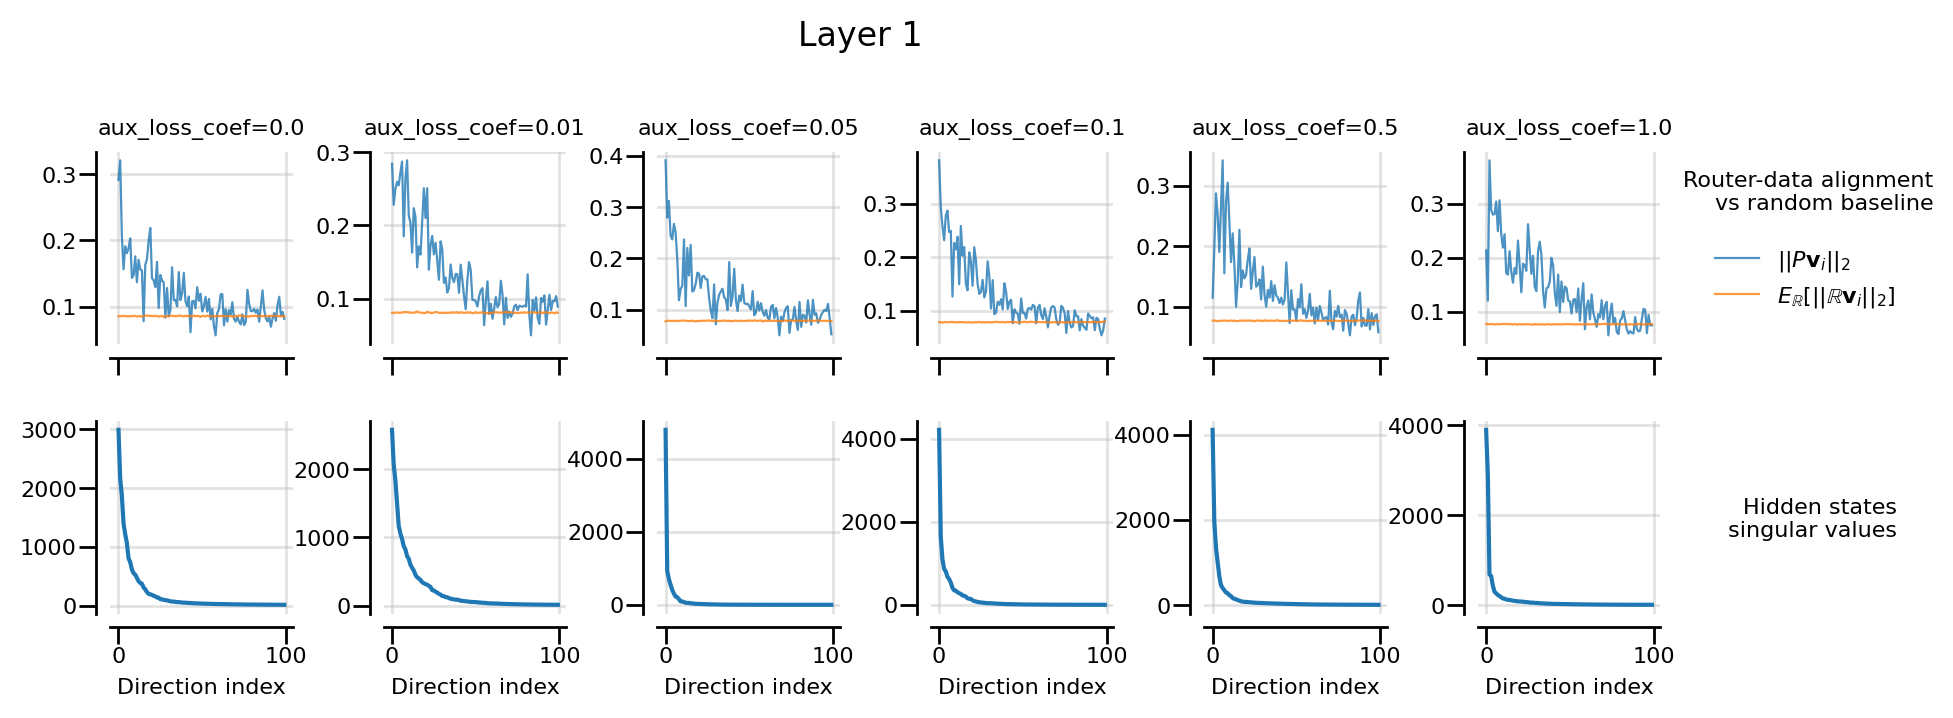

In [16]:
fig, axes = plt.subplots(2, len(full_result_dict),  figsize=(10, 3), sharex='col')
R = 100
fontsize=8
format_figure(axes.flatten(), fontsize=8)
fig.subplots_adjust(wspace=0.5, hspace=0.4)
line_config = {
    'linewidth': 0.8,
    'alpha': 0.8,
}
for i, (key, (alignments, random_alignments, Sig)) in enumerate(all_alignments.items()):
    grad_accum, aux_loss_coef = key
    ax = axes[0, i]
    ax.plot(alignments[:R], label=r'$||P\mathbf{v}_i||_2$', **line_config)
    ax.plot(random_alignments[:R], label=r'$E_{\mathbb{R}}[||\mathbb{R}\mathbf{v}_i||_2]$', **line_config)
    # ax.set_title(f"grad_accum={grad_accum}, aux_loss_coef={aux_loss_coef}")
    # if i == 0:
        # ax.legend()
    ax = axes[1, i]
    ax.plot(Sig[:R])
    # ax.set_yscale("log")

axes_titles = [
    f"aux_loss_coef={aux_loss_coef}"
    for grad_accum, aux_loss_coef in full_result_dict.keys()
]

for ax, title in zip(axes[0, :], axes_titles):
    ax.set_title(title, fontsize=fontsize)

for a in axes[1, :]:
    a.set_xlabel("Direction index", fontsize=fontsize)
# axes[0, 0].set_ylabel("Alignment with Vk", fontsize=fontsize)
# axes[1, 0].set_ylabel("Singular values", fontsize=fontsize)
axes[0, -1].legend(loc='upper right', fontsize=fontsize, frameon=False, bbox_to_anchor=(2.4, 0.6))
axes[0, -1].annotate('Router-data alignment\nvs random baseline', xy=(2.5, 0.7), xycoords='axes fraction', fontsize=fontsize, ha='right')
# axes[0, -1].annotate("Random P alignment", xy=(0.95, 0.8), xycoords='axes fraction', fontsize=fontsize, color='C1', ha='right')
axes[1, -1].annotate("Hidden states\n singular values", xy=(2.3, 0.4), xycoords='axes fraction', fontsize=fontsize, ha='right')
# axes[0, 0].set_title(f"grad_accum={grad_accum}, aux_loss_coef={aux_loss_coef}", fontsize=fontsize)
fig.suptitle(f"Layer {LID}", fontsize=fontsize * 1.5, y=1.1)
plt.show()

In [9]:
full_result_dict = {}
for grad_accum, aux_loss_coef in [
    (1, 0.0),
    (1, 1.0),
    (2, 1.0),
    (4, 1.0),
    (8, 1.0)
    ]:
    full_result_dict[(grad_accum, aux_loss_coef)] = extract_results(grad_accum, aux_loss_coef)

model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.52it/s]


model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.48it/s]


model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:54<00:00,  1.84it/s]


model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [01:47<00:00,  1.07s/it]


model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [03:32<00:00,  2.13s/it]


In [108]:
all_alignments = {}
LID = 9
for key, (inputs, router_weights) in full_result_dict.items():
    origin = inputs[LID][:]
    U, Sig, Vk = np.linalg.svd(origin[:], full_matrices=False)
    P = router_weights[LID].T
    alignments = np.linalg.norm(Vk @ P, axis=1)

    R = sample_random_P(P, n_samples=1000)              # (n_samples, D, K)
    random_alignments = np.linalg.norm(
        Vk @ R,      # (n_samples, r, K)  -- numpy broadcasts over n_samples
        axis=-1        # (n_samples, r)
    ).mean(axis=0)
    all_alignments[key] = (alignments, random_alignments, Sig)     

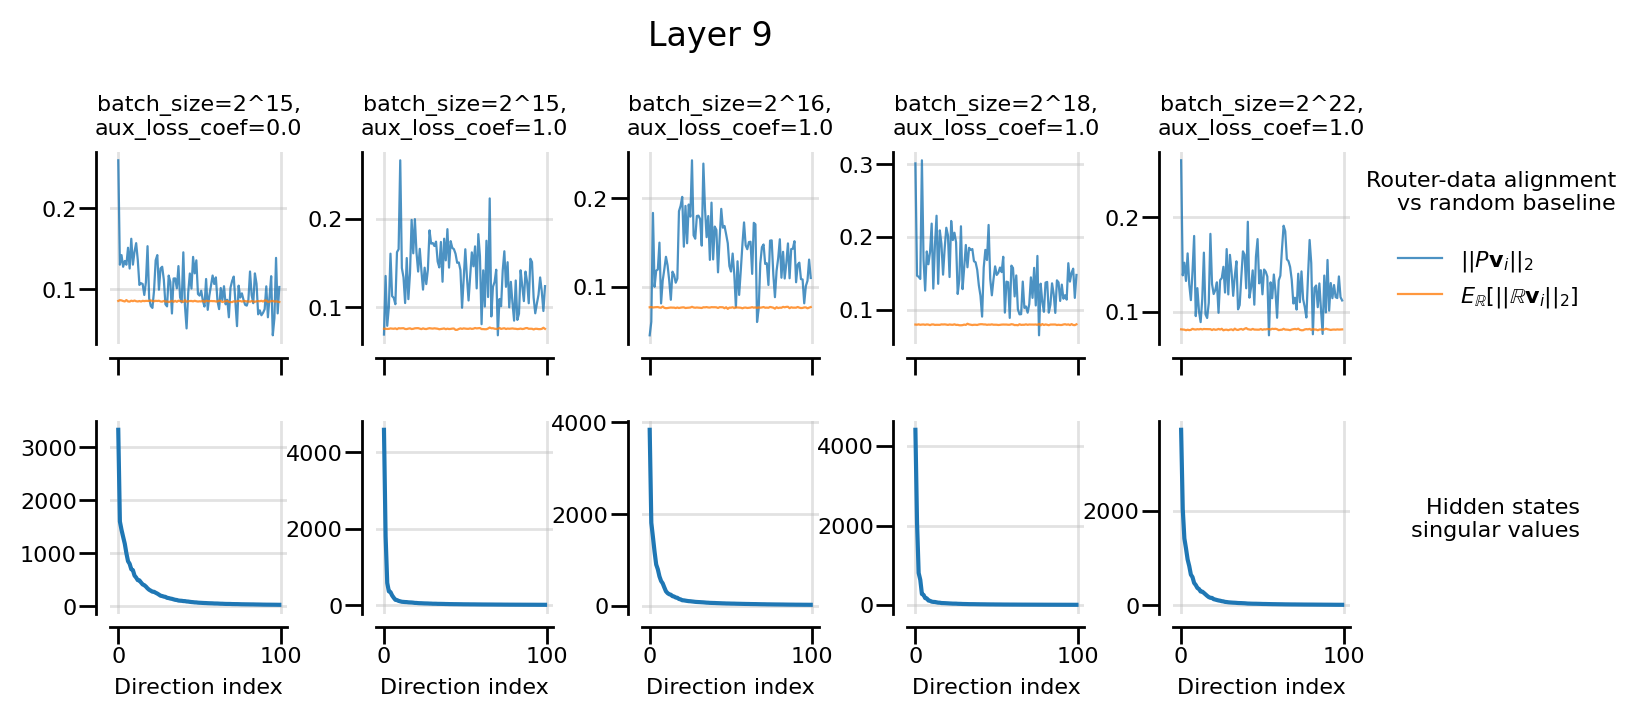

In [109]:
fig, axes = plt.subplots(2, len(full_result_dict),  figsize=(8, 3), sharex='col')
R = 100
fontsize=8
format_figure(axes.flatten(), fontsize=8)
fig.subplots_adjust(wspace=0.5, hspace=0.4)
line_config = {
    'linewidth': 0.8,
    'alpha': 0.8,
}
for i, (key, (alignments, random_alignments, Sig)) in enumerate(all_alignments.items()):
    grad_accum, aux_loss_coef = key
    ax = axes[0, i]
    ax.plot(alignments[:R], label=r'$||P\mathbf{v}_i||_2$', **line_config)
    ax.plot(random_alignments[:R], label=r'$E_{\mathbb{R}}[||\mathbb{R}\mathbf{v}_i||_2]$', **line_config)
    # ax.set_title(f"grad_accum={grad_accum}, aux_loss_coef={aux_loss_coef}")
    # if i == 0:
        # ax.legend()
    ax = axes[1, i]
    ax.plot(Sig[:R])
    # ax.set_yscale("log")

axes_titles = [
    f"batch_size=2^{grad_accum + 14},\naux_loss_coef={aux_loss_coef}"
    for grad_accum, aux_loss_coef in full_result_dict.keys()
]

for ax, title in zip(axes[0, :], axes_titles):
    ax.set_title(title, fontsize=fontsize)

for a in axes[1, :]:
    a.set_xlabel("Direction index", fontsize=fontsize)
# axes[0, 0].set_ylabel("Alignment with Vk", fontsize=fontsize)
# axes[1, 0].set_ylabel("Singular values", fontsize=fontsize)
axes[0, -1].legend(loc='upper right', fontsize=fontsize, frameon=False, bbox_to_anchor=(2.4, 0.6))
axes[0, -1].annotate('Router-data alignment\nvs random baseline', xy=(2.5, 0.7), xycoords='axes fraction', fontsize=fontsize, ha='right')
# axes[0, -1].annotate("Random P alignment", xy=(0.95, 0.8), xycoords='axes fraction', fontsize=fontsize, color='C1', ha='right')
axes[1, -1].annotate("Hidden states\n singular values", xy=(2.3, 0.4), xycoords='axes fraction', fontsize=fontsize, ha='right')
# axes[0, 0].set_title(f"grad_accum={grad_accum}, aux_loss_coef={aux_loss_coef}", fontsize=fontsize)
fig.suptitle(f"Layer {LID}", fontsize=fontsize * 1.5, y=1.1)
plt.show()

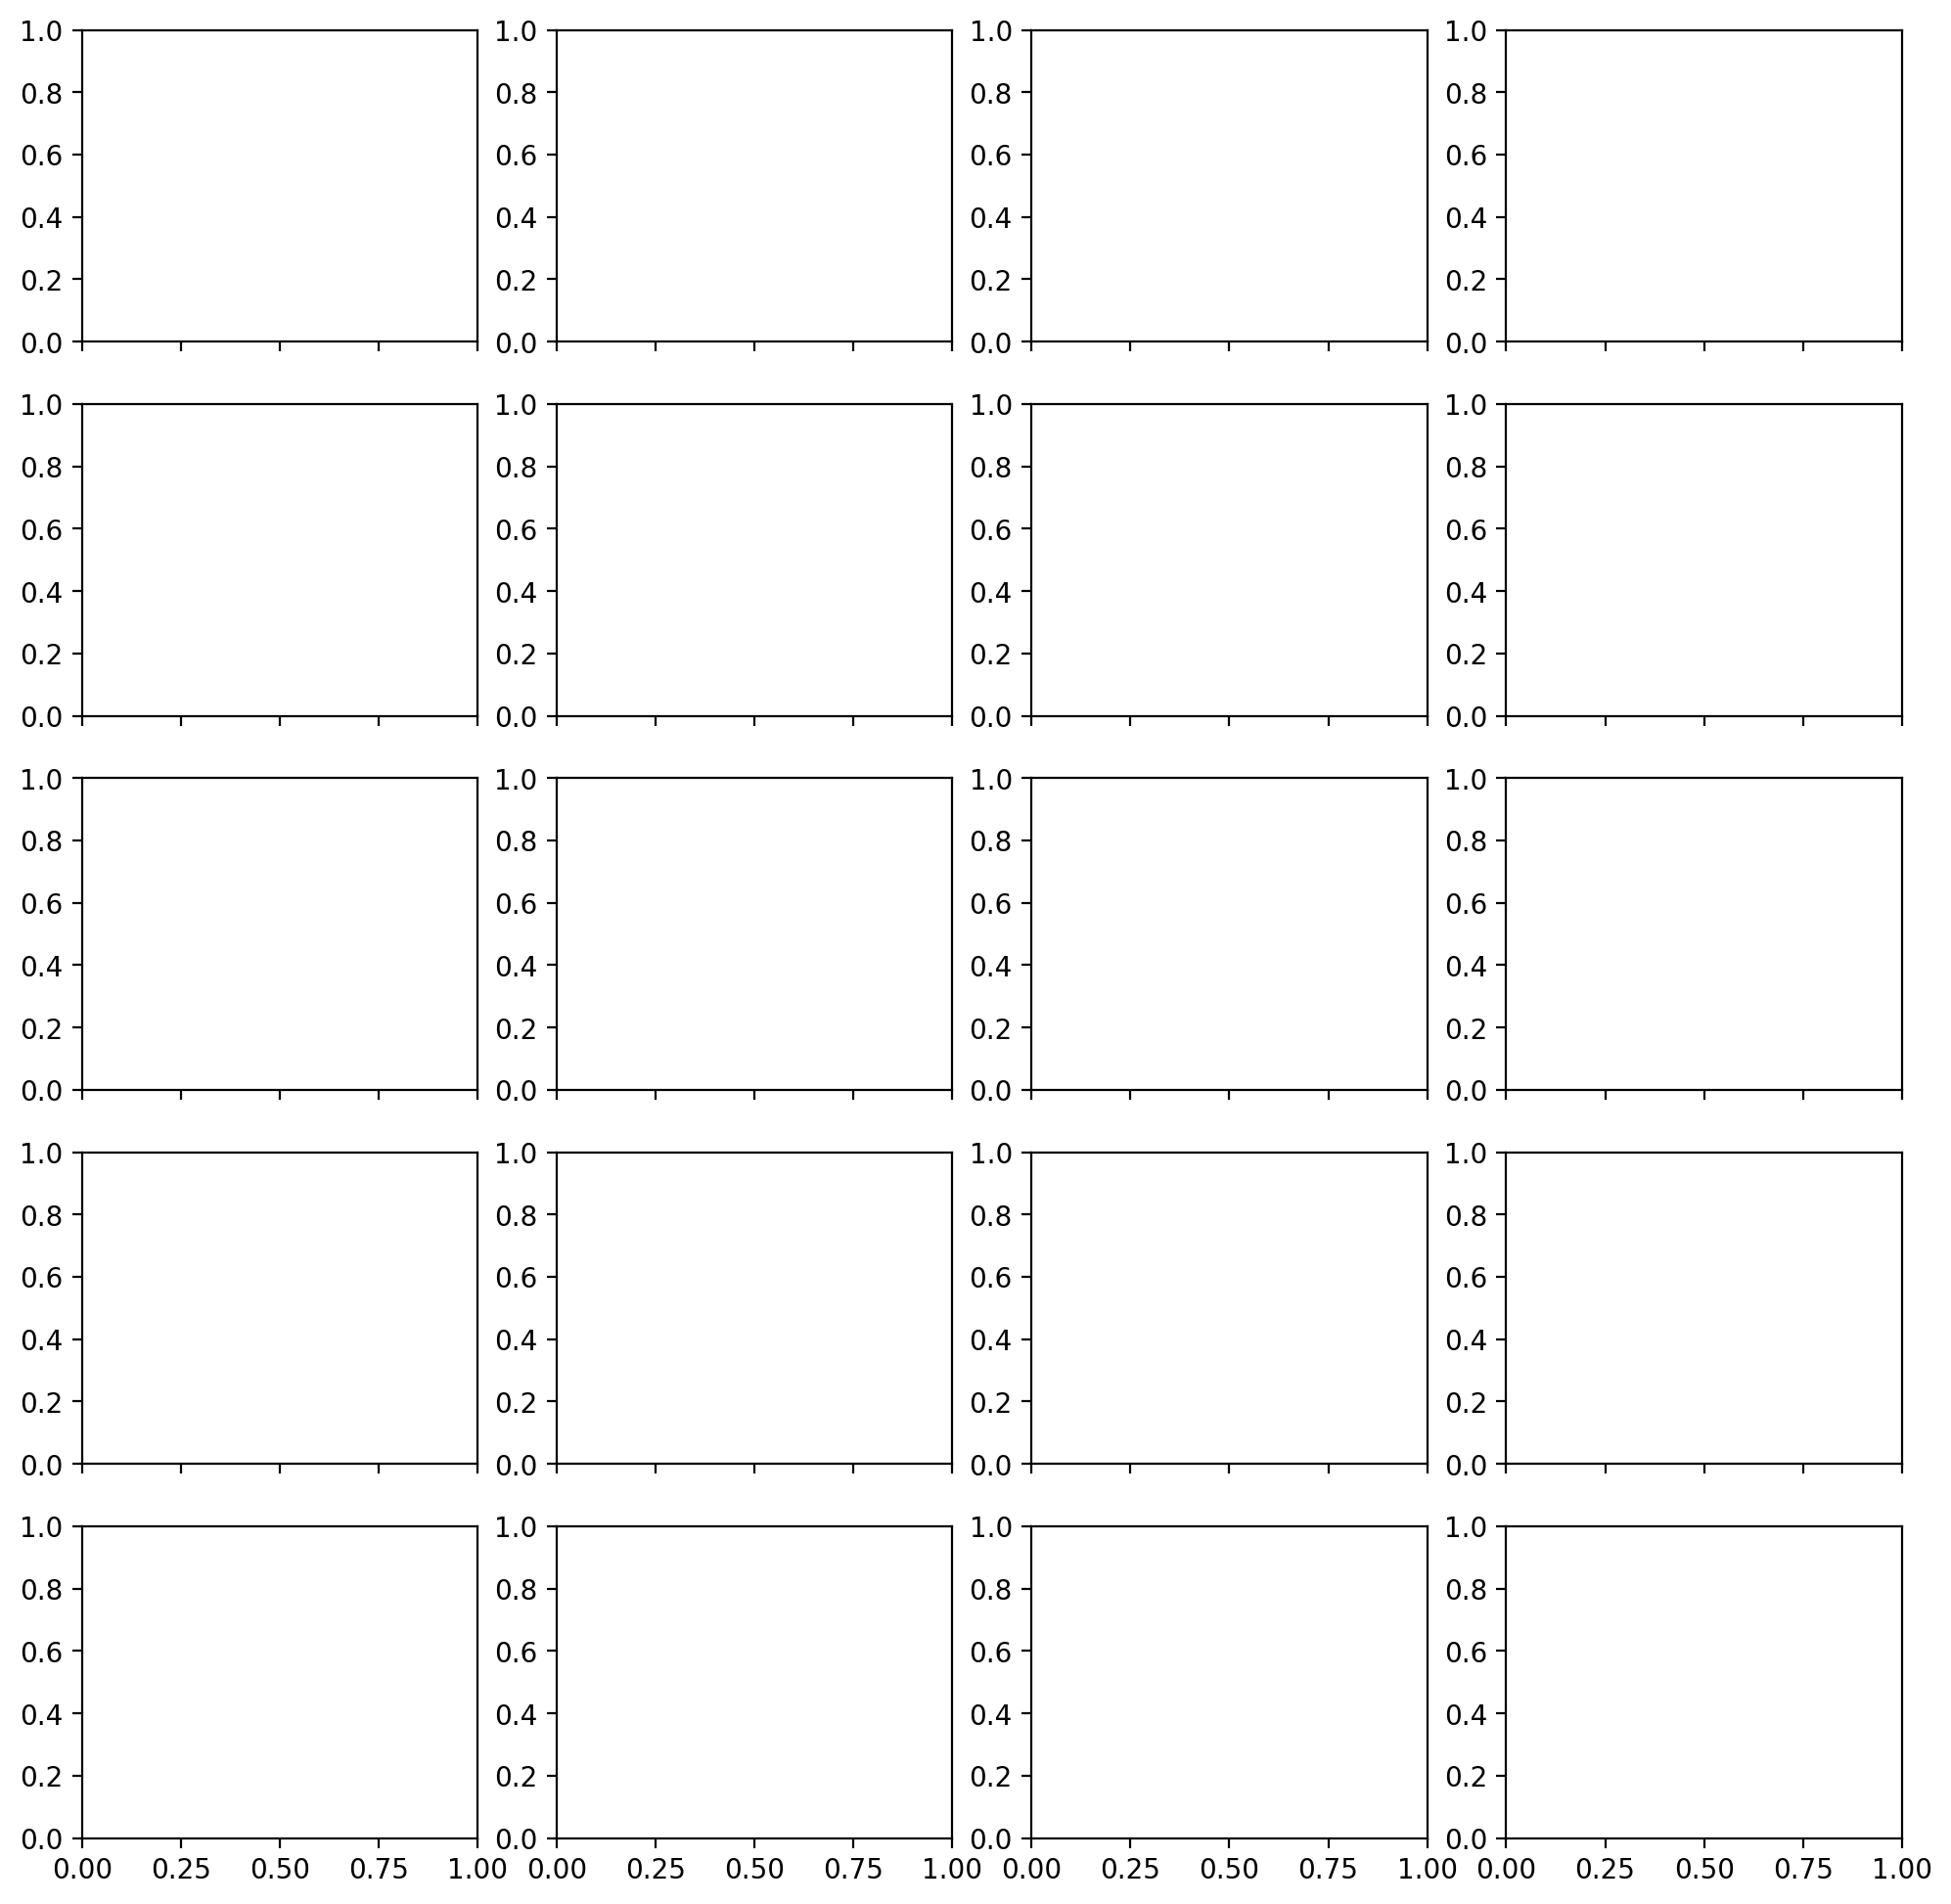

In [11]:
layer_ids = [0, 3, 6, 9]
fig, axes = plt.subplots(len(full_result_dict), len(layer_ids), figsize=(12, 3 * len(layer_ids)), sharex='col')

In [29]:
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
tokenizer.model_max_length = max_seq_len
model_config = MoEConfig.nano()
model_config.vocab_size = len(tokenizer)
model_config.max_position_embeddings = max_seq_len
model_config.attention_type = "flex_attention"

model = create_model(model_config).to(device=device, dtype=dtype)
model.train()
print(f"model_params={model.num_parameters() / 1e6:.1f}M")
lr = 1e-3
optimizers = build_optimizer_adamw(model, lr_adamw=lr, lr_muon=lr, lr_layernorm=lr, wd=weight_decay)
log_adamw, hidden_states_metrics_adamw_no_scaling = run_multiple_steps(
    model,
    optimizers,
    steps=100,
    activate_router_freq=100,
    return_router_monitor=True,
    grad_accum=1,
    # aux_loss_coef=0.5
    # aux_loss_coef=1.0
    aux_loss_coef=0
)

model_params=558.7M


100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.51it/s]


In [30]:
captures, handles = register_router_io_hooks(model, detach=True, to_cpu=True)
with torch.no_grad():
    batch = next(iter(val_dataset))
    batch = batch.to(device, non_blocking=True)
    input_ids = batch.tokens.unsqueeze(0)
    position_ids = batch.position_ids.unsqueeze(0)
    doc_ids, seq_lens = cu_seqlens_to_packing_metadata(batch.cu_seqlens)

    _ = model(
        input_ids=input_ids,
        position_ids=position_ids,
        packing_doc_ids=doc_ids,
        packing_seq_lens=seq_lens,
        use_cache=False,
        return_router_logits=False,
    )

all_inputs = []
all_router_weights = []
for capture in captures:
    all_inputs.append(capture.records[0].inputs.cpu().detach().float().numpy())

for layer in model.modules():
    if hasattr(layer, "gate"):
        all_router_weights.append(layer.gate.weight.cpu().detach().float().numpy())

In [31]:
LID = 4
origin = all_inputs[LID][:]
U, Sig, Vk = np.linalg.svd(origin[:], full_matrices=False)
P = all_router_weights[LID].T
alignments = np.linalg.norm(Vk @ P, axis=1)

R = sample_random_P(P, n_samples=1000)              # (n_samples, D, K)
random_alignments = np.linalg.norm(
    Vk @ R,      # (n_samples, r, K)  -- numpy broadcasts over n_samples
    axis=-1        # (n_samples, r)
).mean(axis=0)       

Text(0.5, 1.0, 'Router data\nalignment')

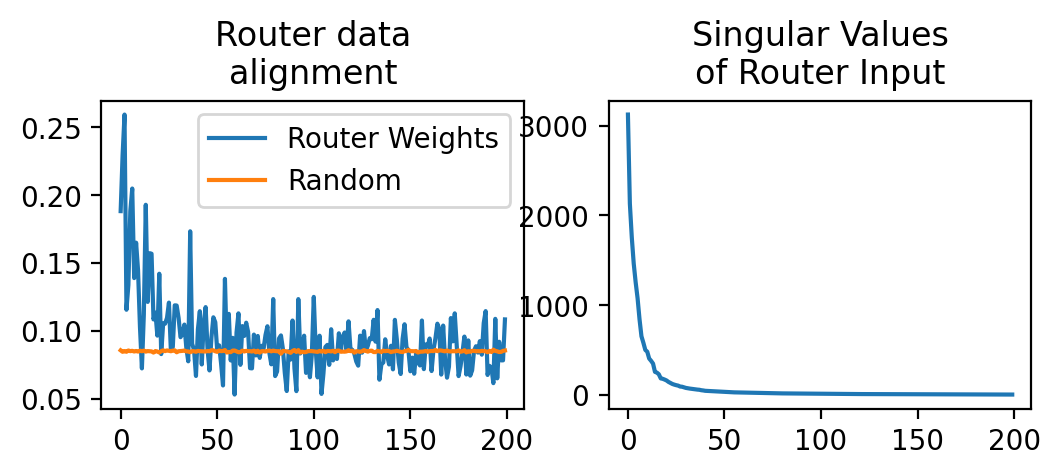

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))

RANGE = 200


cumulative_energy = np.cumsum(Sig) / np.sum(Sig)
rank_95 = np.searchsorted(cumulative_energy, 0.8) + 1

# ax[0].plot(np.cumsum(alignments[:RANGE]), label="Router Weights")
ax[0].plot(alignments[:RANGE], label="Router Weights")
ax[0].plot(random_alignments[:RANGE], label="Random")
# ax[0].axvline(rank_95, color="red", linestyle="--", label=f"95% energy at {rank_95:.0f}")

# compute the index with 95% of the cumulative sum of singular values


ax[1].plot(Sig[:RANGE], label="Singular Values")
# ax[1].axvline(rank_95, color="red", linestyle="--", label=f"95% energy at {rank_95:.0f}")
ax[1].set_title("Singular Values\nof Router Input")
# ax[1].set_yscale("log")
ax[0].legend()
ax[0].set_title("Router data\nalignment")

Text(0.5, 1.0, 'Router data\nalignment')

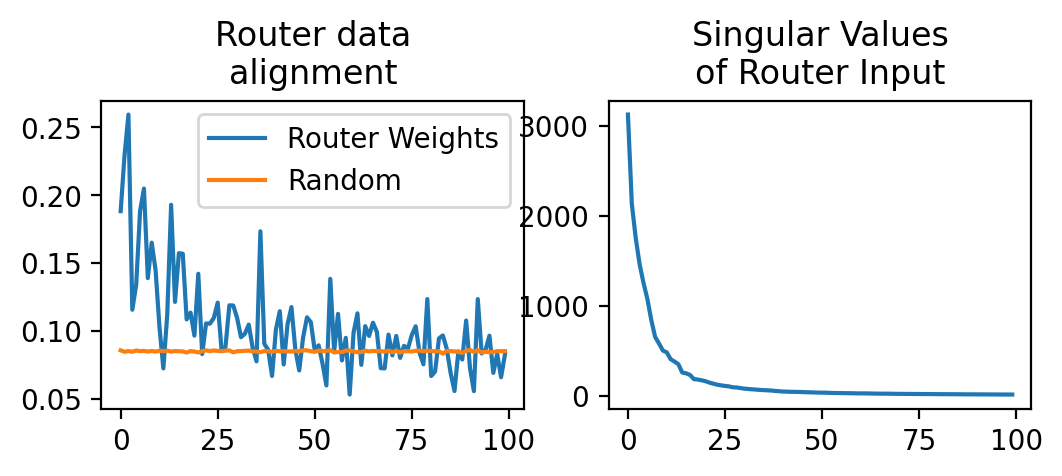

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))

RANGE = 100

ax[0].plot(alignments[:RANGE], label="Router Weights")
ax[0].plot(random_alignments[:RANGE], label="Random")

ax[1].plot(Sig[:RANGE], label="Singular Values")
ax[1].set_title("Singular Values\nof Router Input")
ax[0].legend()
ax[0].set_title("Router data\nalignment")

Text(0.5, 1.0, 'Router data\nalignment')

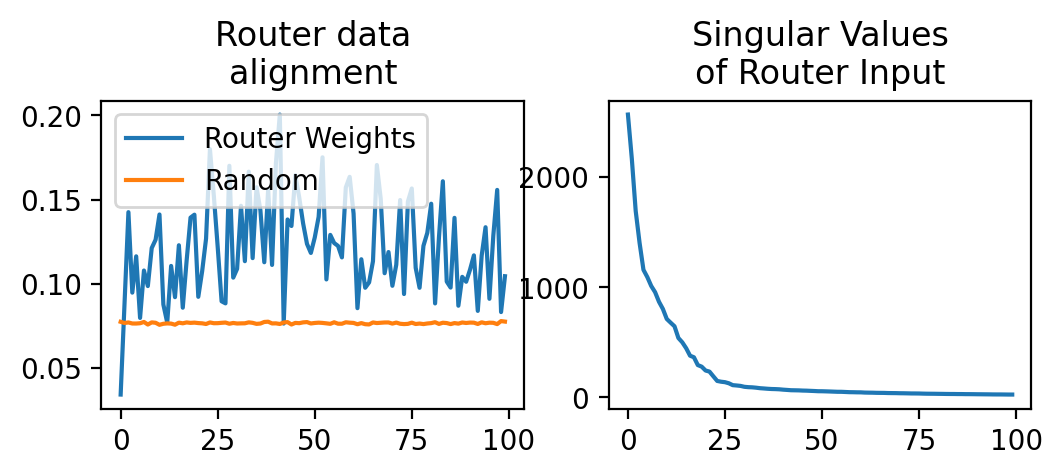

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))

RANGE = 100

ax[0].plot(alignments[:RANGE], label="Router Weights")
ax[0].plot(random_alignments[:RANGE], label="Random")

ax[1].plot(Sig[:RANGE], label="Singular Values")
ax[1].set_title("Singular Values\nof Router Input")
ax[0].legend()
ax[0].set_title("Router data\nalignment")

Text(0.5, 1.0, 'Router data\nalignment')

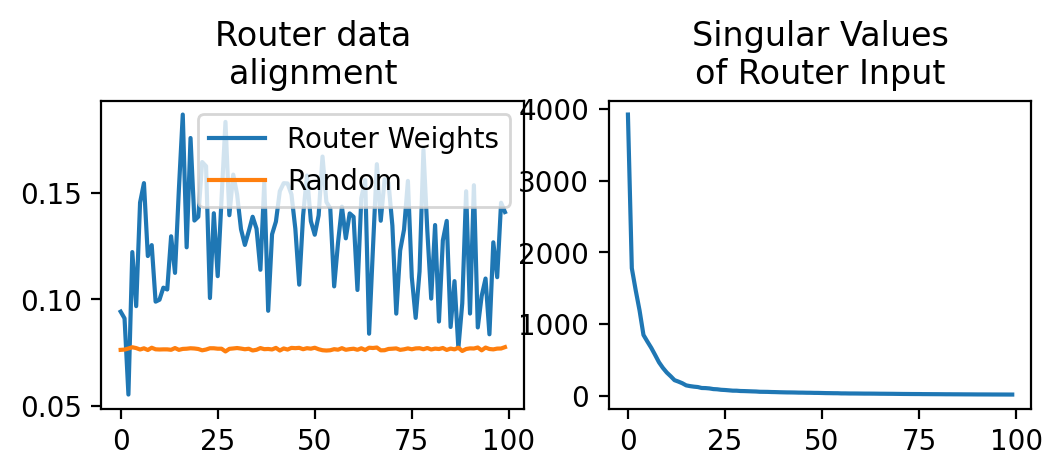

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2))

RANGE = 100

ax[0].plot(alignments[:RANGE], label="Router Weights")
ax[0].plot(random_alignments[:RANGE], label="Random")

ax[1].plot(Sig[:RANGE], label="Singular Values")
ax[1].set_title("Singular Values\nof Router Input")
ax[0].legend()
ax[0].set_title("Router data\nalignment")

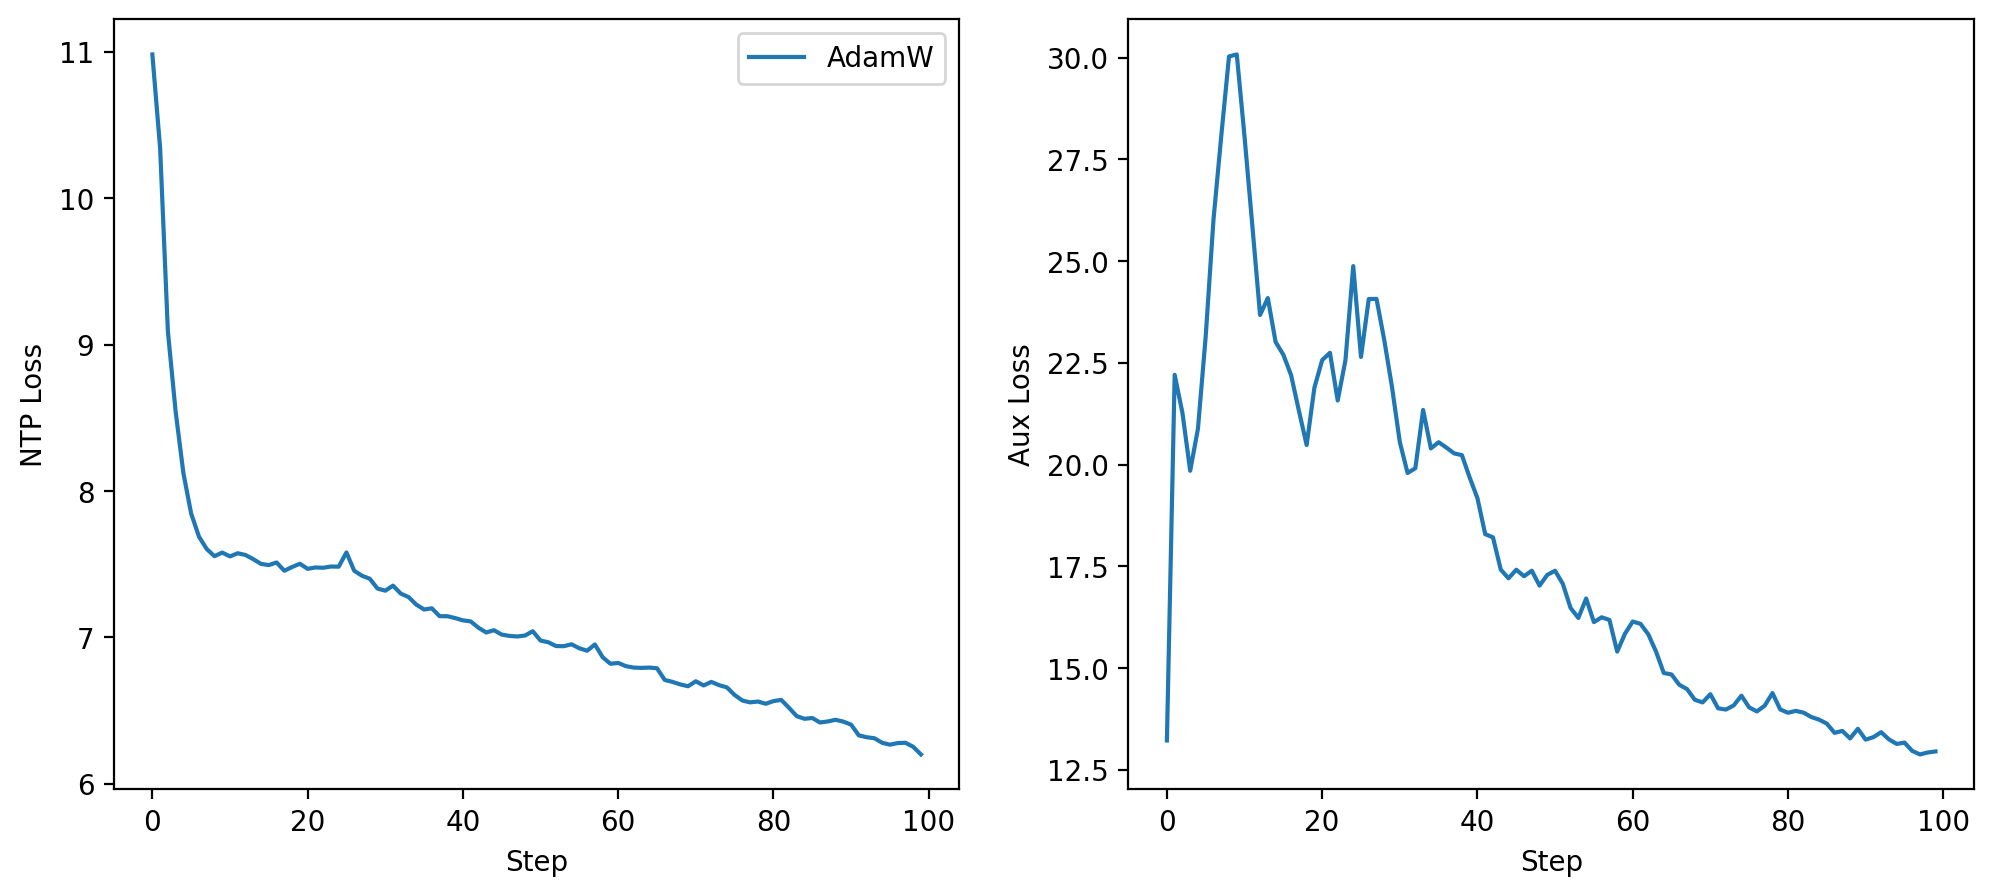

In [29]:
log_dict = {
    'AdamW': log_adamw,
    # 'AdamW with Depth Scaling': log_adamw_with_scaling,
    # 'Muon with Depth Scaling': log_muon_with_scaling,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('aux_loss'), log))
    axes[0].plot(loss, label=name)
    axes[1].plot(aux_loss, label=f"{name} Backward")
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('NTP Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Aux Loss')
axes[0].legend()

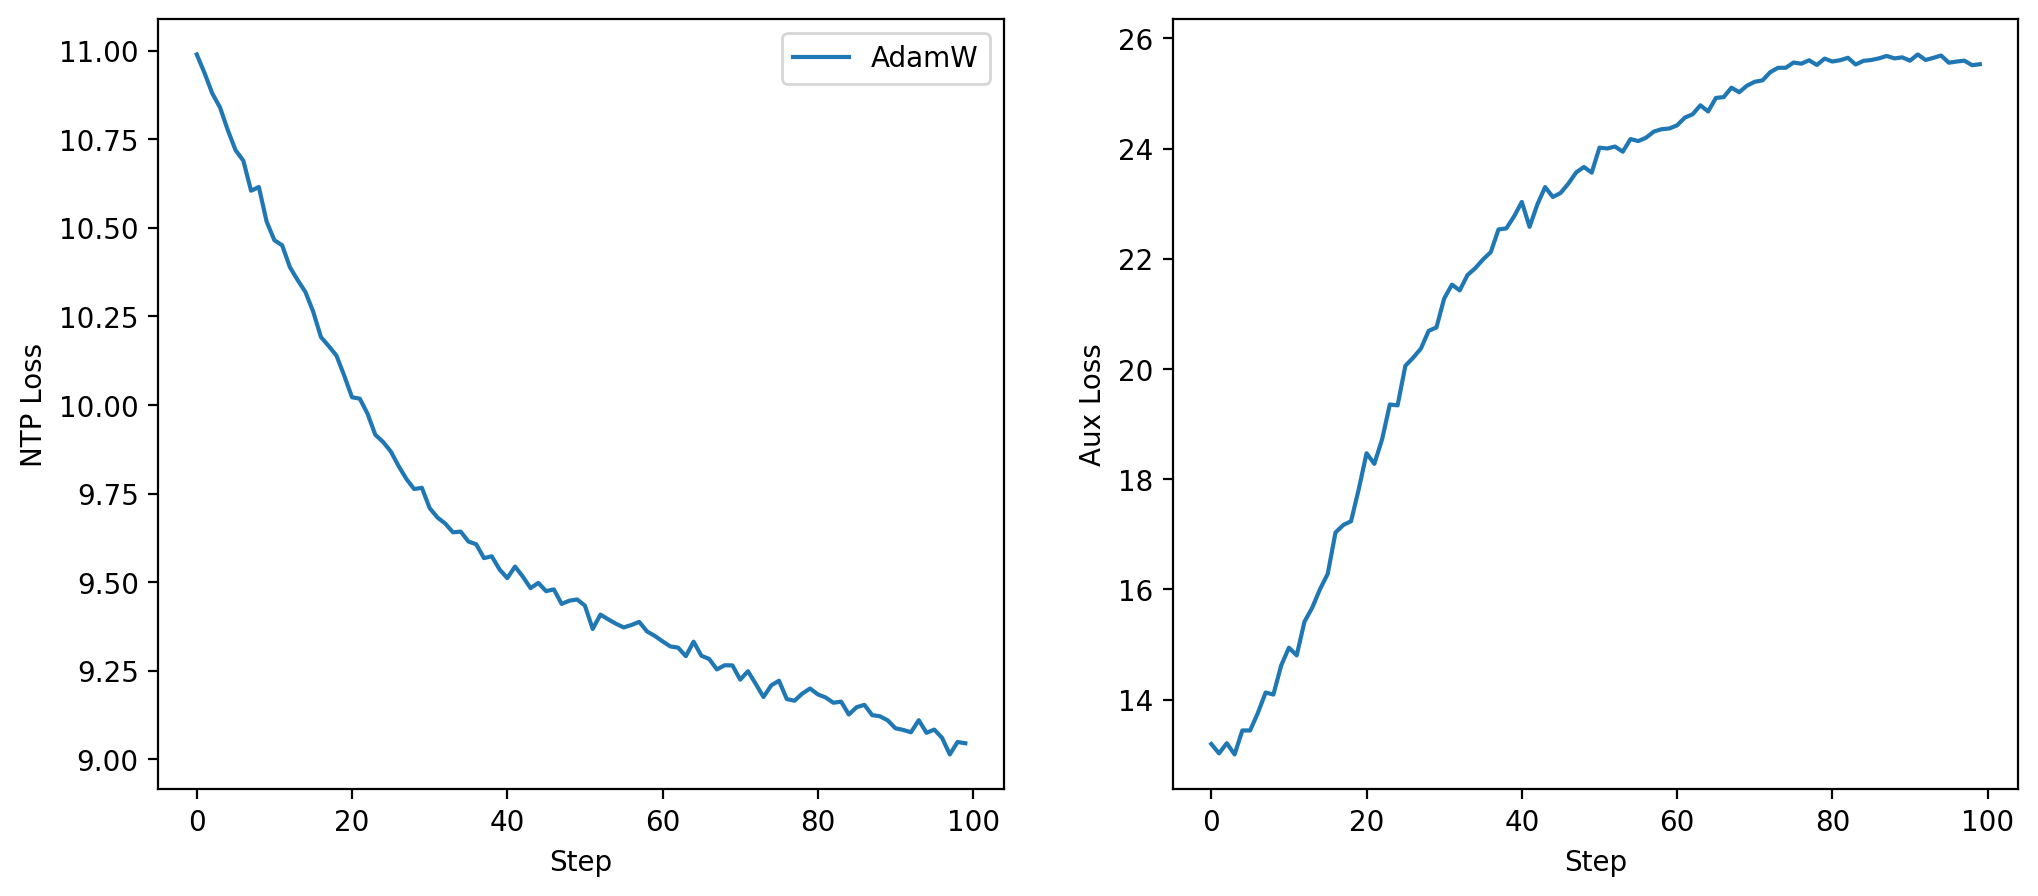

In [16]:
log_dict = {
    'AdamW': log_adamw,
    # 'AdamW with Depth Scaling': log_adamw_with_scaling,
    # 'Muon with Depth Scaling': log_muon_with_scaling,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, log in log_dict.items():
    loss = list(map(itemgetter('loss'), log))
    aux_loss = list(map(itemgetter('aux_loss'), log))
    axes[0].plot(loss, label=name)
    axes[1].plot(aux_loss, label=f"{name} Backward")
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('NTP Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Aux Loss')
axes[0].legend()